In [2]:
import mysql.connector

def get_connection():
    return mysql.connector.connect(
        host="localhost",
        user="root",
        password="",
        database="db_kesehatan_mental"
    )

C:\Users\user\AppData\Local\Temp\ipykernel_10516\4269222657.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM tb_data", conn)



Model tersedia:
['gaussian_nb', 'categorical_nb', 'multinomial_nb', 'knn', 'decision_tree']

===== HASIL MODEL =====
Model: Decision Tree
Accuracy: 0.848
Training Accuracy: 0.8928
F1 Score: 0.7455
Precision: 0.7269
Recall: 0.7996


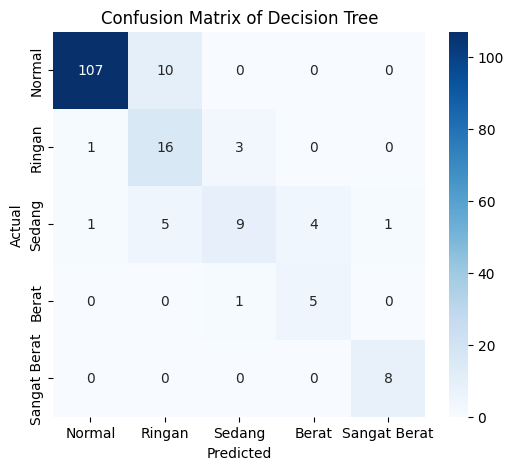

In [ ]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

from sklearn.naive_bayes import GaussianNB, CategoricalNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


# ===============================
# KONEKSI DATABASE
# ===============================
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="db_kesehatan_mental"
)

df = pd.read_sql("SELECT * FROM tb_data", conn)


# ===============================
# PREPROCESSING
# ===============================
df[['P1','P2','P3']] = df[['P1','P2','P3']].astype(str)
df['Kelas'] = df['Kelas'].astype(str)

label_encoder_kelas = LabelEncoder()
df['Kelas_enc'] = label_encoder_kelas.fit_transform(df['Kelas'])

# urutan kelas agar tidak acak
class_order = ["Normal", "Ringan", "Sedang", "Berat", "Sangat Berat"]
ordered_labels = label_encoder_kelas.transform(class_order)

X = df[['P1','P2','P3']]
y = df['Kelas_enc']


# ===============================
# SPLIT DATA
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ===============================
# LABEL ENCODING (Gaussian & Categorical NB)
# ===============================
le_p1 = LabelEncoder()
le_p2 = LabelEncoder()
le_p3 = LabelEncoder()

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc['P1'] = le_p1.fit_transform(X_train_enc['P1'])
X_train_enc['P2'] = le_p2.fit_transform(X_train_enc['P2'])
X_train_enc['P3'] = le_p3.fit_transform(X_train_enc['P3'])

X_test_enc['P1'] = le_p1.transform(X_test_enc['P1'])
X_test_enc['P2'] = le_p2.transform(X_test_enc['P2'])
X_test_enc['P3'] = le_p3.transform(X_test_enc['P3'])


# ===============================
# ONE HOT ENCODING (MultinomialNB, KNN, Tree)
# ===============================
onehot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_onehot = onehot.fit_transform(X_train)
X_test_onehot = onehot.transform(X_test)


# ===============================
# MODEL
# ===============================
models = {

    "gaussian_nb": GaussianNB(),

    "categorical_nb": CategoricalNB(alpha=1.0),

    "multinomial_nb": MultinomialNB(alpha=1.0),

    "knn": KNeighborsClassifier(n_neighbors=7),

    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )
}


# nama model untuk judul plot
model_titles = {

    "gaussian_nb": "Gaussian Naive Bayes",

    "categorical_nb": "Categorical Naive Bayes",

    "multinomial_nb": "Multinomial Naive Bayes",

    "knn": "K-Nearest Neighbor",

    "decision_tree": "Decision Tree"
}


results = {}

for name, model in models.items():

    # pilih dataset sesuai model
    if name in ["gaussian_nb", "categorical_nb"]:
        Xtr = X_train_enc
        Xte = X_test_enc
    else:
        Xtr = X_train_onehot
        Xte = X_test_onehot

    model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_pred_train = model.predict(Xtr)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=ordered_labels
    )

    results[name] = {
        "cm": cm,
        "accuracy": accuracy_score(y_test, y_pred),
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "f1": f1_score(y_test, y_pred, average="macro"),
        "precision": precision_score(y_test, y_pred, average="macro"),
        "recall": recall_score(y_test, y_pred, average="macro")
    }


# ===============================
# INPUT MODEL
# ===============================
print("\nModel tersedia:")
print(list(models.keys()))

model_input = input("\nMasukkan nama model: ").strip()

if model_input not in results:
    print("Model tidak ditemukan")
    exit()

res = results[model_input]


# ===============================
# METRICS
# ===============================
print("\n===== HASIL MODEL =====")

print("Model:", model_titles[model_input])
print("Accuracy:", round(res["accuracy"],4))
print("Training Accuracy:", round(res["train_accuracy"],4))
print("F1 Score:", round(res["f1"],4))
print("Precision:", round(res["precision"],4))
print("Recall:", round(res["recall"],4))


# ===============================
# CONFUSION MATRIX PLOT
# ===============================
plt.figure(figsize=(6,5))

sns.heatmap(
    res["cm"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title(f"Confusion Matrix of {model_titles[model_input]}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [1]:
def get_all(query, params=None):
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute(query, params or ())

    results = cursor.fetchall()
    cursor.close()
    conn.close()

    return results

def execute_query(query, params=None):
    conn = get_connection()
    cursor = conn.cursor()
    cursor.execute(query, params or ())

    conn.commit()
    cursor.close()
    conn.close()

In [2]:
conn = get_connection()

data_training = get_all("SELECT * FROM tb_data WHERE Jenis = 'Training'")

NameError: name 'get_connection' is not defined

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

columns = [
    "kd_data", "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "A1", "A2", "A3", "A4", "A5", "A6", "A7",
    "S1", "S2", "S3", "S4", "S5", "S6", "S7", "P1", "P2", "P3", "Kelas", "Jenis"
]

dropCols = [
    "kd_data", "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "A1", "A2", "A3", "A4", "A5", "A6", "A7",
    "S1", "S2", "S3", "S4", "S5", "S6", "S7", "Jenis", "Kelas"
]

dfTrain = pd.DataFrame(data_training, columns=columns)
dfTest = pd.DataFrame(data_training, columns=columns)

# Lakukan encoding data
targetColumns = ['P1', 'P2', 'P3']
labelColumn = 'Kelas'
le = LabelEncoder()

dfTrain = dfTrain.copy()
dfTest = dfTest.copy()

encoders = {}

# Encoding P1-P3
for col in targetColumns:
    le = LabelEncoder()
    dfTrain[col] = le.fit_transform(dfTrain[col])
    dfTest[col] = le.transform(dfTest[col])
    encoders[col] = le

# Encode label 
leKelas = LabelEncoder()
dfTrain[labelColumn] = leKelas.fit_transform(dfTrain[labelColumn])
dfTest[labelColumn] = leKelas.transform(dfTest[labelColumn])

dfAll = pd.concat([dfTrain, dfTest])

In [ ]:
dfAll

,kd_data,D1,D2,D3,D4,D5,D6,D7,A1,A2,...,S3,S4,S5,S6,S7,P1,P2,P3,Kelas,Jenis
0,UID_1,Kadang-kadang,Lumayan Sering,Kadang-kadang,Tidak Pernah,Tidak Pernah,Tidak Pernah,Tidak Pernah,Kadang-kadang,Tidak Pernah,...,Tidak Pernah,Tidak Pernah,Tidak Pernah,Tidak Pernah,Tidak Pernah,1,1,1,1,Training
1,UID_100,Kadang-kadang,Lumayan Sering,Lumayan Sering,Lumayan Sering,Lumayan Sering,Lumayan Sering,Lumayan Sering,Lumayan Sering,Kadang-kadang,...,Lumayan Sering,Lumayan Sering,Lumayan Sering,Kadang-kadang,Lumayan Sering,4,4,2,4,Training
2,UID_103,Tidak Pernah,Sering Sekali,Sering Sekali,Kadang-kadang,Kadang-kadang,Lumayan Sering,Kadang-kadang,Sering Sekali,Tidak Pernah,...,Tidak Pernah,Kadang-kadang,Tidak Pernah,Lumayan Sering,Kadang-kadang,4,4,1,2,Training
3,UID_104,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Tidak Pernah,Tidak Pernah,Kadang-kadang,Lumayan Sering,Tidak Pernah,...,Tidak Pernah,Kadang-kadang,Kadang-kadang,Lumayan Sering,Lumayan Sering,1,2,1,1,Training
4,UID_106,Kadang-kadang,Kadang-kadang,Tidak Pernah,Tidak Pernah,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Lumayan Sering,...,Tidak Pernah,Lumayan Sering,Kadang-kadang,Tidak Pernah,Sering Sekali,1,4,1,1,Training
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,UID_95,Kadang-kadang,Lumayan Sering,Tidak Pernah,Kadang-kadang,Tidak Pernah,Kadang-kadang,Tidak Pernah,Lumayan Sering,Sering Sekali,...,Sering Sekali,Lumayan Sering,Kadang-kadang,Tidak Pernah,Lumayan Sering,1,0,2,4,Training
677,UID_96,Tidak Pernah,Kadang-kadang,Tidak Pernah,Tidak Pernah,Kadang-kadang,Tidak Pernah,Tidak Pernah,Sering Sekali,Tidak Pernah,...,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Lumayan Sering,1,2,1,1,Training
678,UID_97,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Tidak Pernah,...,Kadang-kadang,Kadang-kadang,Kadang-kadang,Kadang-kadang,Sering Sekali,1,2,1,1,Training
679,UID_98,Kadang-kadang,Lumayan Sering,Kadang-kadang,Kadang-kadang,Kadang-kadang,Kadang-kadang,Tidak Pernah,Sering Sekali,Tidak Pernah,...,Tidak Pernah,Kadang-kadang,Lumayan Sering,Kadang-kadang,Kadang-kadang,2,4,1,2,Training


In [ ]:
dfTest

,kd_data,D1,D2,D3,D4,D5,D6,D7,A1,A2,...,S3,S4,S5,S6,S7,P1,P2,P3,Kelas,Jenis
0,UID_1,Kadang-kadang,Lumayan Sering,Kadang-kadang,Tidak Pernah,Tidak Pernah,Tidak Pernah,Tidak Pernah,Kadang-kadang,Tidak Pernah,...,Tidak Pernah,Tidak Pernah,Tidak Pernah,Tidak Pernah,Tidak Pernah,1,1,1,1,Training
1,UID_100,Kadang-kadang,Lumayan Sering,Lumayan Sering,Lumayan Sering,Lumayan Sering,Lumayan Sering,Lumayan Sering,Lumayan Sering,Kadang-kadang,...,Lumayan Sering,Lumayan Sering,Lumayan Sering,Kadang-kadang,Lumayan Sering,4,4,2,4,Training
2,UID_103,Tidak Pernah,Sering Sekali,Sering Sekali,Kadang-kadang,Kadang-kadang,Lumayan Sering,Kadang-kadang,Sering Sekali,Tidak Pernah,...,Tidak Pernah,Kadang-kadang,Tidak Pernah,Lumayan Sering,Kadang-kadang,4,4,1,2,Training
3,UID_104,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Tidak Pernah,Tidak Pernah,Kadang-kadang,Lumayan Sering,Tidak Pernah,...,Tidak Pernah,Kadang-kadang,Kadang-kadang,Lumayan Sering,Lumayan Sering,1,2,1,1,Training
4,UID_106,Kadang-kadang,Kadang-kadang,Tidak Pernah,Tidak Pernah,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Lumayan Sering,...,Tidak Pernah,Lumayan Sering,Kadang-kadang,Tidak Pernah,Sering Sekali,1,4,1,1,Training
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676,UID_95,Kadang-kadang,Lumayan Sering,Tidak Pernah,Kadang-kadang,Tidak Pernah,Kadang-kadang,Tidak Pernah,Lumayan Sering,Sering Sekali,...,Sering Sekali,Lumayan Sering,Kadang-kadang,Tidak Pernah,Lumayan Sering,1,0,2,4,Training
677,UID_96,Tidak Pernah,Kadang-kadang,Tidak Pernah,Tidak Pernah,Kadang-kadang,Tidak Pernah,Tidak Pernah,Sering Sekali,Tidak Pernah,...,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Lumayan Sering,1,2,1,1,Training
678,UID_97,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Kadang-kadang,Kadang-kadang,Tidak Pernah,Kadang-kadang,Tidak Pernah,...,Kadang-kadang,Kadang-kadang,Kadang-kadang,Kadang-kadang,Sering Sekali,1,2,1,1,Training
679,UID_98,Kadang-kadang,Lumayan Sering,Kadang-kadang,Kadang-kadang,Kadang-kadang,Kadang-kadang,Tidak Pernah,Sering Sekali,Tidak Pernah,...,Tidak Pernah,Kadang-kadang,Lumayan Sering,Kadang-kadang,Kadang-kadang,2,4,1,2,Training


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter
from imblearn.over_sampling import SMOTENC

dropCols = [
    "kode_data", "D1", "D2", "D3", "D4", "D5", "D6", "D7",
    "A1", "A2", "A3", "A4", "A5", "A6", "A7",
    "S1", "S2", "S3", "S4", "S5", "S6", "S7", "Jenis", "Kelas"
]

xTrain = dfTrain[['P1', 'P2', 'P3']]
yTrain = dfTrain['Kelas']
xTest = dfTest[['P1', 'P2', 'P3']]
yTest = dfTest['Kelas']

# xTrain, xTest, yTrain, yTest = train_test_split(dfAll[['P1', 'P2', 'P3']], dfAll['Kelas'], test_size=0.2, random_state=42, stratify=dfAll['Kelas'])

# One-Hot Encoding untuk fitur kategori (Naive Bayes)
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
xTrainEnc = encoder.fit_transform(xTrain)
xTestEnc = encoder.transform(xTest)

# Encode target label
leTarget = LabelEncoder()
yTrainEnc = leTarget.fit_transform(yTrain)
yTestEnc = leTarget.transform(yTest)

# Gunakan SMOTE ENC karena bisa menangani fitur kategori:
# categorical_features = list(range(xTrainEnc.shape[1]))

# smote_nc = SMOTENC(categorical_features=categorical_features, random_state=42)
# xTrainSmote, yTrainSmote = smote_nc.fit_resample(xTrainEnc, yTrainEnc)

# Terapkan SMOTE
# smote = SMOTE(random_state=42)
# xTrainSmote, yTrainSmote = smote.fit_resample(xTrainEnc, yTrainEnc)

# print("Setelah SMOTE:", Counter(yTrainSmote))

In [ ]:
xTrain

,P1,P2,P3
0,1,1,1
1,4,4,2
2,4,4,1
3,1,2,1
4,1,4,1
...,...,...,...
676,1,0,2
677,1,2,1
678,1,2,1
679,2,4,1


In [ ]:
yTrain

0      1
1      4
2      4
3      4
4      1
      ..
677    4
678    1
679    1
680    2
681    4
Name: Kelas, Length: 682, dtype: int64

In [ ]:
xTest

,P1,P2,P3
0,1,1,1
1,1,1,1
2,1,1,1
3,1,1,1
4,1,1,1
...,...,...,...
165,1,1,1
166,1,1,1
167,1,1,1
168,1,1,1


In [ ]:
yTest

194    1
103    3
200    4
475    1
142    1
      ..
320    4
124    0
115    3
75     1
211    1
Name: Kelas, Length: 171, dtype: int64

In [ ]:
# Latih Model

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

nbModel = MultinomialNB(alpha=1.0)
treeModel = DecisionTreeClassifier(random_state=42, class_weight='balanced')
knnModel = KNeighborsClassifier(n_neighbors=5)
svmModel = SVC(kernel='linear', probability=True, class_weight='balanced')

# Training
knnModel.fit(xTrainEnc, yTrainEnc)
yPredKnn = knnModel.predict(xTestEnc)

treeModel.fit(xTrainEnc, yTrainEnc)
yPredTree = treeModel.predict(xTestEnc)

nbModel.fit(xTrainEnc, yTrainEnc)
yPredNb = nbModel.predict(xTestEnc)

svmModel.fit(xTrainEnc, yTrainEnc)
yPredSvm = svmModel.predict(xTestEnc)

# import numpy as np
# unique, counts = np.unique(yTest, return_counts=True)
# print(dict(zip(leKelas.inverse_transform(unique), counts)))

def getValue(type, pred):
    if (type == 'acc'):
        return accuracy_score(yTestEnc, pred)
    elif (type == 'f1-score'):
        return f1_score(yTestEnc, pred, average='macro')    
    elif (type == 'precision'):
        return precision_score(yTestEnc, pred, average='macro')
    else:
        return recall_score(yTestEnc, pred, average='macro')

data = {
    'Model': ['K-NN', 'Decision Tree', 'Naive Bayes', 'SVM'],
    'Akurasi': [getValue('acc', yPredKnn), getValue('acc', yPredTree), getValue('acc', yPredNb), getValue('acc', yPredSvm)],
    'F1-Score': [getValue('f1-score', yPredKnn), getValue('f1-score', yPredTree), getValue('f1-score', yPredNb), getValue('f1-score', yPredSvm)],
    'Precision Score': [getValue('precision', yPredKnn), getValue('precision', yPredTree), getValue('precision', yPredNb), getValue('precision', yPredSvm)],
    'Recall Score': [getValue('recall', yPredKnn), getValue('recall', yPredTree), getValue('recall', yPredNb), getValue('recall', yPredSvm)]
}

evaluasiDf = pd.DataFrame(data)

# Evaluasi Per Model
print('Confusion Matrix K-NN')
print(classification_report(yTestEnc, yPredKnn, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix Decision Tree")
print(classification_report(yTestEnc, yPredTree, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix Naive Bayes")
print(classification_report(yTestEnc, yPredNb, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix SVM")
print(classification_report(yTestEnc, yPredSvm, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

Confusion Matrix K-NN
              precision    recall  f1-score   support

       Berat       0.80      0.62      0.70        26
      Normal       0.97      0.97      0.97       466
      Ringan       0.68      0.84      0.75        80
Sangat Berat       0.91      0.94      0.92        31
      Sedang       0.89      0.69      0.78        78

    accuracy                           0.91       681
   macro avg       0.85      0.81      0.82       681
weighted avg       0.92      0.91      0.91       681

Confusion Matrix Decision Tree
              precision    recall  f1-score   support

       Berat       0.74      0.96      0.83        26
      Normal       1.00      0.90      0.95       466
      Ringan       0.56      0.95      0.71        80
Sangat Berat       1.00      0.94      0.97        31
      Sedang       0.95      0.73      0.83        78

    accuracy                           0.89       681
   macro avg       0.85      0.90      0.86       681
weighted avg       0.93 

In [ ]:
evaluasiDf

,Model,Akurasi,F1-Score,Precision Score,Recall Score
0,K-NN,0.910426,0.822598,0.847256,0.810985
1,Decision Tree,0.892805,0.856039,0.848706,0.896245
2,Naive Bayes,0.906021,0.816603,0.824505,0.812693
3,SVM,0.878120,0.839194,0.837256,0.887555


In [ ]:
# Latih Model Lakukan Teknik SMOTE dan Split Data Acak

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

nbModel = MultinomialNB(alpha=1.0)
treeModel = DecisionTreeClassifier(random_state=42, class_weight='balanced')
knnModel = KNeighborsClassifier(n_neighbors=3)
svmModel = SVC(kernel='linear', probability=True, class_weight='balanced')

# Training
knnModel.fit(xTrainSmote, yTrainSmote)
yPredKnn = knnModel.predict(xTestEnc)

treeModel.fit(xTrainSmote, yTrainSmote)
yPredTree = treeModel.predict(xTestEnc)

nbModel.fit(xTrainSmote, yTrainSmote)
yPredNb = nbModel.predict(xTestEnc)

svmModel.fit(xTrainSmote, yTrainSmote)
yPredSvm = svmModel.predict(xTestEnc)

# import numpy as np
# unique, counts = np.unique(yTest, return_counts=True)
# print(dict(zip(leKelas.inverse_transform(unique), counts)))

def getValue(type, pred):
    if (type == 'acc'):
        return accuracy_score(yTestEnc, pred)
    elif (type == 'f1-score'):
        return f1_score(yTestEnc, pred, average='weighted')    
    elif (type == 'precision'):
        return precision_score(yTestEnc, pred, average='weighted')
    else:
        return recall_score(yTestEnc, pred, average='weighted')

data = {
    'Model': ['K-NN', 'Decision Tree', 'Naive Bayes', 'SVM'],
    'Akurasi': [getValue('acc', yPredKnn), getValue('acc', yPredTree), getValue('acc', yPredNb), getValue('acc', yPredSvm)],
    'F1-Score': [getValue('f1-score', yPredKnn), getValue('f1-score', yPredTree), getValue('f1-score', yPredNb), getValue('f1-score', yPredSvm)],
    'Precision Score': [getValue('precision', yPredKnn), getValue('precision', yPredTree), getValue('precision', yPredNb), getValue('precision', yPredSvm)],
    'Recall Score': [getValue('recall', yPredKnn), getValue('recall', yPredTree), getValue('recall', yPredNb), getValue('recall', yPredSvm)]
}

evaluasiDf = pd.DataFrame(data)

# Evaluasi Per Model
print('Confusion Matrix K-NN')
print(classification_report(yTestEnc, yPredKnn, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix Decision Tree")
print(classification_report(yTestEnc, yPredTree, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix Naive Bayes")
print(classification_report(yTestEnc, yPredNb, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix SVM")
print(classification_report(yTestEnc, yPredSvm, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

Confusion Matrix K-NN
              precision    recall  f1-score   support

       Berat       0.67      0.67      0.67         6
      Normal       0.98      0.97      0.98       117
      Ringan       0.67      0.70      0.68        20
Sangat Berat       0.89      1.00      0.94         8
      Sedang       0.68      0.65      0.67        20

    accuracy                           0.89       171
   macro avg       0.78      0.80      0.79       171
weighted avg       0.90      0.89      0.89       171

Confusion Matrix Decision Tree
              precision    recall  f1-score   support

       Berat       1.00      0.67      0.80         6
      Normal       0.98      0.91      0.95       117
      Ringan       0.53      0.85      0.65        20
Sangat Berat       0.89      1.00      0.94         8
      Sedang       0.76      0.65      0.70        20

    accuracy                           0.87       171
   macro avg       0.83      0.82      0.81       171
weighted avg       0.90 

In [ ]:
evaluasiDf

,Model,Akurasi,F1-Score,Precision Score,Recall Score
0,K-NN,0.894737,0.894799,0.895388,0.894737
1,Decision Tree,0.871345,0.878643,0.899903,0.871345
2,Naive Bayes,0.853801,0.863217,0.887419,0.853801
3,SVM,0.859649,0.864161,0.886842,0.859649


In [ ]:
# Latih Model Hanya Menggunakan Split Konsisten dan Acak

from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

nbModel = MultinomialNB(alpha=1.0)
treeModel = DecisionTreeClassifier(random_state=42, class_weight='balanced')
knnModel = KNeighborsClassifier(n_neighbors=3)
svmModel = SVC(kernel='linear', probability=True, class_weight='balanced')

# Training
knnModel.fit(xTrainEnc, yTrainEnc)
yPredKnn = knnModel.predict(xTestEnc)

treeModel.fit(xTrainEnc, yTrainEnc)
yPredTree = treeModel.predict(xTestEnc)

nbModel.fit(xTrainEnc, yTrainEnc)
yPredNb = nbModel.predict(xTestEnc)

svmModel.fit(xTrainEnc, yTrainEnc)
yPredSvm = svmModel.predict(xTestEnc)

# import numpy as np
# unique, counts = np.unique(yTest, return_counts=True)
# print(dict(zip(leKelas.inverse_transform(unique), counts)))

def getValue(type, pred):
    if (type == 'acc'):
        return accuracy_score(yTestEnc, pred)
    elif (type == 'f1-score'):
        return f1_score(yTestEnc, pred, average='weighted')    
    elif (type == 'precision'):
        return precision_score(yTestEnc, pred, average='weighted')
    else:
        return recall_score(yTestEnc, pred, average='weighted')

data = {
    'Model': ['K-NN', 'Decision Tree', 'Naive Bayes', 'SVM'],
    'Akurasi': [getValue('acc', yPredKnn), getValue('acc', yPredTree), getValue('acc', yPredNb), getValue('acc', yPredSvm)],
    'F1-Score': [getValue('f1-score', yPredKnn), getValue('f1-score', yPredTree), getValue('f1-score', yPredNb), getValue('f1-score', yPredSvm)],
    'Precision Score': [getValue('precision', yPredKnn), getValue('precision', yPredTree), getValue('precision', yPredNb), getValue('precision', yPredSvm)],
    'Recall Score': [getValue('recall', yPredKnn), getValue('recall', yPredTree), getValue('recall', yPredNb), getValue('recall', yPredSvm)]
}

evaluasiDf = pd.DataFrame(data)

# Evaluasi Per Model
print('Confusion Matrix K-NN')
print(classification_report(yTestEnc, yPredKnn, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix Decision Tree")
print(classification_report(yTestEnc, yPredTree, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix Naive Bayes")
print(classification_report(yTestEnc, yPredNb, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

print("Confusion Matrix SVM")
print(classification_report(yTestEnc, yPredSvm, labels=range(len(leKelas.classes_)), target_names=leKelas.classes_, zero_division=0))

Confusion Matrix K-NN
              precision    recall  f1-score   support

       Berat       0.75      0.50      0.60         6
      Normal       0.93      0.97      0.95       117
      Ringan       0.60      0.15      0.24        20
Sangat Berat       0.89      1.00      0.94         8
      Sedang       0.60      0.90      0.72        20

    accuracy                           0.85       171
   macro avg       0.75      0.70      0.69       171
weighted avg       0.84      0.85      0.83       171

Confusion Matrix Decision Tree
              precision    recall  f1-score   support

       Berat       0.56      0.83      0.67         6
      Normal       0.98      0.92      0.95       117
      Ringan       0.53      0.80      0.64        20
Sangat Berat       0.89      1.00      0.94         8
      Sedang       0.69      0.45      0.55        20

    accuracy                           0.85       171
   macro avg       0.73      0.80      0.75       171
weighted avg       0.88 

In [ ]:
evaluasiDf

,Model,Akurasi,F1-Score,Precision Score,Recall Score
0,K-NN,0.853801,0.827365,0.842398,0.853801
1,Decision Tree,0.853801,0.857128,0.876199,0.853801
2,Naive Bayes,0.906433,0.906135,0.908302,0.906433
3,SVM,0.859649,0.864161,0.886842,0.859649


C:\Users\user\AppData\Local\Temp\ipykernel_280\1225817210.py:30: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM tb_data", conn)
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000021 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15
[LightGBM] [Info] Number of data points in the train set: 681, number of used features: 3
[LightGBM] [Info] Start training from score -3.265466
[LightGBM] [Info] Start training from score -0.379377
[LightGBM] [Info] Start training from score -2.141536
[LightGBM] [Info] Start training from score -3.089575
[LightGBM] [Info] Start training from score -2.166853
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightG

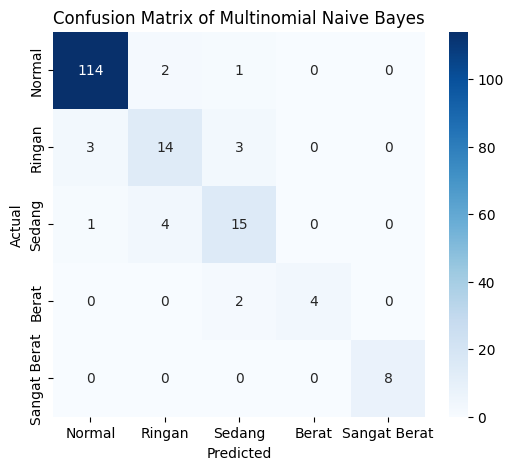

In [5]:
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

from sklearn.naive_bayes import GaussianNB, CategoricalNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ===============================
# KONEKSI DATABASE
# ===============================
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="db_kesehatan_mental"
)

df = pd.read_sql("SELECT * FROM tb_data", conn)


# ===============================
# PREPROCESSING
# ===============================
df[['P1','P2','P3']] = df[['P1','P2','P3']].astype(str)
df['Kelas'] = df['Kelas'].astype(str)

label_encoder_kelas = LabelEncoder()
df['Kelas_enc'] = label_encoder_kelas.fit_transform(df['Kelas'])

class_order = ["Normal", "Ringan", "Sedang", "Berat", "Sangat Berat"]
ordered_labels = label_encoder_kelas.transform(class_order)

X = df[['P1','P2','P3']]
y = df['Kelas_enc']


# ===============================
# SPLIT DATA
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ===============================
# LABEL ENCODING
# ===============================
le_p1 = LabelEncoder()
le_p2 = LabelEncoder()
le_p3 = LabelEncoder()

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc['P1'] = le_p1.fit_transform(X_train_enc['P1'])
X_train_enc['P2'] = le_p2.fit_transform(X_train_enc['P2'])
X_train_enc['P3'] = le_p3.fit_transform(X_train_enc['P3'])

X_test_enc['P1'] = le_p1.transform(X_test_enc['P1'])
X_test_enc['P2'] = le_p2.transform(X_test_enc['P2'])
X_test_enc['P3'] = le_p3.transform(X_test_enc['P3'])


# ===============================
# ONE HOT ENCODING
# ===============================
onehot = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_train_onehot = onehot.fit_transform(X_train)
X_test_onehot = onehot.transform(X_test)


# ===============================
# MODEL
# ===============================
models = {

    "gaussian_nb": GaussianNB(),

    "categorical_nb": CategoricalNB(alpha=1.0),

    "multinomial_nb": MultinomialNB(alpha=1.0),

    "knn": KNeighborsClassifier(
        n_neighbors=7
    ),

    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "logistic_regression": LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        multi_class="multinomial"
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "radius_neighbors": RadiusNeighborsClassifier(
        radius=1.5,
        weights="distance"
    ),

    "xgboost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        eval_metric="mlogloss",
        random_state=42
    ),

    "lightgbm": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ),

    "catboost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_state=42
    )
}


# ===============================
# NAMA MODEL
# ===============================
model_titles = {
    "gaussian_nb": "Gaussian Naive Bayes",
    "categorical_nb": "Categorical Naive Bayes",
    "multinomial_nb": "Multinomial Naive Bayes",
    "knn": "K-Nearest Neighbor",
    "decision_tree": "Decision Tree",
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
    "radius_neighbors": "Radius Neighbors",
    "xgboost": "XGBoost",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost"
}


# ===============================
# TRAINING
# ===============================
results = {}

for name, model in models.items():

    if name in ["gaussian_nb", "categorical_nb", "lightgbm"]:
        Xtr = X_train_enc
        Xte = X_test_enc

    elif name == "catboost":
        Xtr = X_train
        Xte = X_test

    else:
        Xtr = X_train_onehot
        Xte = X_test_onehot

    # khusus CatBoost
    if name == "catboost":
        model.fit(
            Xtr,
            y_train,
            cat_features=[0,1,2]
        )
    else:
        model.fit(Xtr, y_train)

    y_pred = model.predict(Xte)
    y_pred_train = model.predict(Xtr)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=ordered_labels
    )

    results[name] = {

        "cm": cm,

        "accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "train_accuracy": accuracy_score(
            y_train,
            y_pred_train
        ),

        "f1": f1_score(
            y_test,
            y_pred,
            average="macro"
        ),

        "precision": precision_score(
            y_test,
            y_pred,
            average="macro"
        ),

        "recall": recall_score(
            y_test,
            y_pred,
            average="macro"
        )
    }


# ===============================
# INPUT MODEL
# ===============================
print("\nModel tersedia:")
print(list(models.keys()))

model_input = input("\nMasukkan nama model: ").strip()

if model_input not in results:
    print("Model tidak ditemukan")
    exit()

res = results[model_input]


# ===============================
# METRICS
# ===============================
print("\n===== HASIL MODEL =====")

print("Model:", model_titles[model_input])
print("Accuracy:", round(res["accuracy"],4))
print("Training Accuracy:", round(res["train_accuracy"],4))
print("Precision:", round(res["precision"],4))
print("Recall:", round(res["recall"],4))
print("F1 Score:", round(res["f1"],4))


# ===============================
# CONFUSION MATRIX PLOT
# ===============================
plt.figure(figsize=(6,5))

sns.heatmap(
    res["cm"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title(
    f"Confusion Matrix of {model_titles[model_input]}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_3064\2492335345.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM tb_data", conn)
c:\Users\user\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 15
[LightGBM] [Info] Number of data points in the train set: 2330, number of used features: 3
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

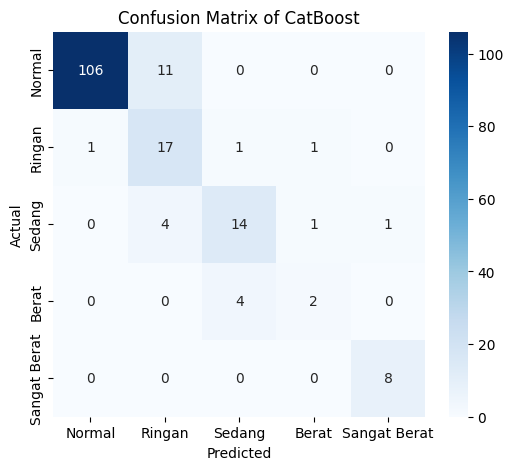

In [11]:
# Dengan SMOTE
import pandas as pd
import mysql.connector
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

from sklearn.naive_bayes import GaussianNB, CategoricalNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import SMOTE  # =============================== TAMBAHAN

# ===============================
# KONEKSI DATABASE
# ===============================
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="",
    database="db_kesehatan_mental"
)

df = pd.read_sql("SELECT * FROM tb_data", conn)


# ===============================
# PREPROCESSING
# ===============================
df[['P1','P2','P3']] = df[['P1','P2','P3']].astype(str)
df['Kelas'] = df['Kelas'].astype(str)

label_encoder_kelas = LabelEncoder()
df['Kelas_enc'] = label_encoder_kelas.fit_transform(df['Kelas'])

class_order = ["Normal", "Ringan", "Sedang", "Berat", "Sangat Berat"]
ordered_labels = label_encoder_kelas.transform(class_order)

X = df[['P1','P2','P3']]
y = df['Kelas_enc']


# ===============================
# SPLIT DATA
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ===============================
# LABEL ENCODING
# ===============================
le_p1 = LabelEncoder()
le_p2 = LabelEncoder()
le_p3 = LabelEncoder()

X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

X_train_enc['P1'] = le_p1.fit_transform(X_train_enc['P1'])
X_train_enc['P2'] = le_p2.fit_transform(X_train_enc['P2'])
X_train_enc['P3'] = le_p3.fit_transform(X_train_enc['P3'])

X_test_enc['P1'] = le_p1.transform(X_test_enc['P1'])
X_test_enc['P2'] = le_p2.transform(X_test_enc['P2'])
X_test_enc['P3'] = le_p3.transform(X_test_enc['P3'])


# ===============================
# ONE HOT ENCODING
# ===============================
onehot = OneHotEncoder(
    sparse_output=False,
    handle_unknown="ignore"
)

X_train_onehot = onehot.fit_transform(X_train)
X_test_onehot = onehot.transform(X_test)


# ===============================
# SMOTE (TAMBAHAN)
# ===============================
smote = SMOTE(random_state=42)

# untuk model encoded
X_train_enc_smote, y_train_smote = smote.fit_resample(X_train_enc, y_train)

# untuk model onehot
X_train_onehot_smote, y_train_onehot_smote = smote.fit_resample(X_train_onehot, y_train)

# untuk catboost (pakai encoded dulu, lalu balik ke dataframe numerik)
X_train_cat_smote, y_train_cat_smote = smote.fit_resample(X_train_enc, y_train)


# hitung distribusi kelas setelah SMOTE
class_counts = pd.Series(y_train_smote).value_counts().sort_index()

class_distribution = {
    label_encoder_kelas.inverse_transform([i])[0]: int(class_counts[i])
    for i in class_counts.index
}


# ===============================
# MODEL
# ===============================
models = {

    "gaussian_nb": GaussianNB(),

    "categorical_nb": CategoricalNB(alpha=1.0),

    "multinomial_nb": MultinomialNB(alpha=1.0),

    "knn": KNeighborsClassifier(
        n_neighbors=7
    ),

    "decision_tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "logistic_regression": LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        multi_class="multinomial"
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "radius_neighbors": RadiusNeighborsClassifier(
        radius=1.5,
        weights="distance"
    ),

    "xgboost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=4,
        eval_metric="mlogloss",
        random_state=42
    ),

    "lightgbm": LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ),

    "catboost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=6,
        verbose=0,
        random_state=42
    )
}


# ===============================
# NAMA MODEL
# ===============================
model_titles = {
    "gaussian_nb": "Gaussian Naive Bayes",
    "categorical_nb": "Categorical Naive Bayes",
    "multinomial_nb": "Multinomial Naive Bayes",
    "knn": "K-Nearest Neighbor",
    "decision_tree": "Decision Tree",
    "logistic_regression": "Logistic Regression",
    "random_forest": "Random Forest",
    "radius_neighbors": "Radius Neighbors",
    "xgboost": "XGBoost",
    "lightgbm": "LightGBM",
    "catboost": "CatBoost"
}


# ===============================
# TRAINING
# ===============================
results = {}

for name, model in models.items():

    if name in ["gaussian_nb", "categorical_nb", "lightgbm"]:
        Xtr = X_train_enc_smote
        ytr = y_train_smote
        Xte = X_test_enc

    elif name == "catboost":
        Xtr = X_train_cat_smote
        ytr = y_train_cat_smote
        Xte = X_test_enc

    else:
        Xtr = X_train_onehot_smote
        ytr = y_train_onehot_smote
        Xte = X_test_onehot

    # khusus CatBoost
    if name == "catboost":
        model.fit(
            Xtr,
            ytr,
            cat_features=[0,1,2]
        )
    else:
        model.fit(Xtr, ytr)

    y_pred = model.predict(Xte)
    y_pred_train = model.predict(Xtr)

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=ordered_labels
    )

    results[name] = {

        "cm": cm,

        "accuracy": accuracy_score(
            y_test,
            y_pred
        ),

        "train_accuracy": accuracy_score(
            ytr,
            y_pred_train
        ),

        "f1": f1_score(
            y_test,
            y_pred,
            average="micro"
        ),

        "precision": precision_score(
            y_test,
            y_pred,
            average="micro"
        ),

        "recall": recall_score(
            y_test,
            y_pred,
            average="micro"
        ),

        "class_distribution_after_smote": class_distribution  # ================= TAMBAHAN
    }

# ===============================
# INPUT MODEL
# ===============================
print("\nModel tersedia:")
print(list(models.keys()))

model_input = input("\nMasukkan nama model: ").strip()

if model_input not in results:
    print("Model tidak ditemukan")
    exit()

res = results[model_input]


# ===============================
# METRICS
# ===============================
print("\n===== HASIL MODEL =====")

print("Model:", model_titles[model_input])
print("Accuracy:", round(res["accuracy"],4))
print("Training Accuracy:", round(res["train_accuracy"],4))
print("Precision:", round(res["precision"],4))
print("Recall:", round(res["recall"],4))
print("F1 Score:", round(res["f1"],4))

# ===============================
# DISTRIBUSI KELAS SETELAH SMOTE (TAMBAHAN)
# ===============================
print("\nDistribusi kelas setelah SMOTE:")
for k, v in res["class_distribution_after_smote"].items():
    print(f"{k}: {v}")


# ===============================
# CONFUSION MATRIX PLOT
# ===============================
plt.figure(figsize=(6,5))

sns.heatmap(
    res["cm"],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_order,
    yticklabels=class_order
)

plt.title(
    f"Confusion Matrix of {model_titles[model_input]}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()